In [16]:
!pip install torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 --index-url https://download.pytorch.org/whl/cu121
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric -f https://data.pyg.org/whl/torch-2.5.1+cu121.html

Looking in indexes: https://download.pytorch.org/whl/cu121
Looking in links: https://data.pyg.org/whl/torch-2.5.1+cu121.html


In [32]:
import torch
import torch.nn as nn
from torch.nn import Sequential, Linear, ReLU
from torch_geometric.nn import PointNetConv, fps, radius, global_max_pool
import numpy as np
from scipy.spatial import ConvexHull, cKDTree

In [18]:
class SetAbstractionLayer(torch.nn.Module):
    def __init__(self, in_channels, mlp_out_channels, ratio=0.5, r=0.2):
        super().__init__()
        self.ratio = ratio
        self.r = r

        # The MLP that will process the local geometric features
        self.mlp = Sequential(
            Linear(in_channels, mlp_out_channels // 2),
            ReLU(),
            Linear(mlp_out_channels // 2, mlp_out_channels),
            ReLU()
        )
        self.conv = PointNetConv(local_nn=self.mlp)

    def forward(self, x, pos, batch):
        # 1. Farthest Point Sampling (selects centroids)
        idx = fps(pos, batch, ratio=self.ratio)

        # 2. Radius Graph (groups neighboring points around centroids)
        row, col = radius(pos, pos[idx], self.r, batch, batch[idx], max_num_neighbors=64)
        edge_index = torch.stack([col, row], dim=0)

        # 3. Apply PointNet Convolution to the grouped points
        # If x is None (first layer), we only use the geometric positions
        x_out = self.conv(x, (pos, pos[idx]), edge_index)

        pos_out = pos[idx]
        batch_out = batch[idx]

        return x_out, pos_out, batch_out

In [35]:

def apply_laplacian_smoothing(points, k=6, iterations=1, lambda_factor=0.25):
    smoothed_points = np.copy(points)
    for _ in range(iterations):
        tree = cKDTree(smoothed_points)
        _, indices = tree.query(smoothed_points, k=k+1)
        neighbor_means = np.mean(smoothed_points[indices[:, 1:]], axis=1)
        smoothed_points = smoothed_points + lambda_factor * (neighbor_means - smoothed_points)
    return smoothed_points

In [19]:
def compute_sphericity(vertices):
    from scipy.spatial import ConvexHull
    import numpy as np

    hull = ConvexHull(vertices)

    if hull.area == 0:
        return 0.0

    sphericity = (np.pi ** (1.0 / 3.0) * (6.0 * hull.volume) ** (2.0 / 3.0)) / hull.area
    return sphericity

In [20]:
class CVAE(nn.Module):
    def __init__(self, latent_dim=128, num_points=1024):
        super().__init__()
        self.num_points = num_points
        self.latent_dim = latent_dim

        self.sa1 = SetAbstractionLayer(in_channels=6, mlp_out_channels=128)
        self.sa2 = SetAbstractionLayer(in_channels=131, mlp_out_channels=256)

        self.fc_mu = Linear(258, latent_dim)
        self.fc_logvar = Linear(258, latent_dim)

        self.decoder_mlp = Sequential(
            Linear(latent_dim + 2, 512),
            ReLU(),
            Linear(512, 1024),
            ReLU(),
            Linear(1024, num_points * 3)
        )

    def encode(self, data, condition):
        x, pos, batch = data.x, data.pos, data.batch

        x1, pos1, batch1 = self.sa1(x, pos, batch)
        x2, pos2, batch2 = self.sa2(x1, pos1, batch1)

        global_feature = global_max_pool(x2, batch2)

        conditioned_feature = torch.cat([global_feature, condition], dim=1)

        return self.fc_mu(conditioned_feature), self.fc_logvar(conditioned_feature)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, condition):
        z_c = torch.cat([z, condition], dim=1)
        output = self.decoder_mlp(z_c)
        return output.view(-1, self.num_points, 3)

    def forward(self, data):
        condition = data.y.view(-1, 2)

        mu, logvar = self.encode(data, condition)
        z = self.reparameterize(mu, logvar)
        reconstructed_points = self.decode(z, condition)

        return reconstructed_points, mu, logvar

In [21]:

def project_to_2d(vertices, theta, phi):
    R_z = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0,             0,              1]
    ])

    R_y = np.array([
        [ np.cos(phi), 0, np.sin(phi)],
        [ 0,           1, 0          ],
        [-np.sin(phi), 0, np.cos(phi)]
    ])

    rotated_3d = vertices @ (R_y @ R_z).T
    return rotated_3d[:, :2]


def solve_containment_inequalities(vertices, faces, params):
    u, v, theta_p, phi_p, alpha, theta_q, phi_q = params

    Q_2d = project_to_2d(vertices, theta_q, phi_q)
    hull_Q = ConvexHull(Q_2d)

    A_mat = hull_Q.equations[:, :2]
    b_vec = -hull_Q.equations[:, 2]

    P_2d_raw = project_to_2d(vertices, theta_p, phi_p)

    R_alpha = np.array([
        [np.cos(alpha), -np.sin(alpha)],
        [np.sin(alpha),  np.cos(alpha)]
    ])

    P_2d = P_2d_raw @ R_alpha.T

    hull_P = ConvexHull(P_2d)
    P_verts = P_2d[hull_P.vertices]

    denom = A_mat @ P_verts.T

    num = b_vec[:, None] - A_mat @ np.array([u, v])[:, None]

    if np.any(num < 0):
        return 0.0

    valid_denoms = denom > 1e-8

    if not np.any(valid_denoms):
        return 0.0

    ratios = num / denom
    max_mu = np.min(ratios[valid_denoms])

    return max_mu

In [22]:
import numpy as np
from scipy.optimize import minimize

def compute_nieuwland_constant(vertices, faces, num_restarts=25):
    """
    Module 2: 7D Optimization to find the exact Nieuwland constant.
    Now utilizes Multi-Start random initializations to escape the 1.0 local minimum.
    """
    best_mu = 0.0

    def objective_function(x):
        mu = solve_containment_inequalities(vertices, faces, x)
        return -mu

    # 1. Try the baseline trivial solution first
    baseline_result = minimize(objective_function, np.zeros(7), method='Nelder-Mead')
    best_mu = max(best_mu, -baseline_result.fun)

    # 2. Multi-start random initializations
    for _ in range(num_restarts):
        # Generate random starting angles between -pi and pi, and slight random translations
        random_guess = np.random.uniform(low=-np.pi, high=np.pi, size=7)

        # Run Nelder-Mead from this new random orientation
        result = minimize(objective_function, random_guess, method='Nelder-Mead')

        # If this random start found a better passage, update our record
        found_mu = -result.fun
        if found_mu > best_mu:
            best_mu = found_mu

    return best_mu

In [34]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import numpy as np

def visualize_generated_polyhedron(vertices, faces):
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')

    mesh = Poly3DCollection(vertices[faces], alpha=0.8, edgecolor='black', linewidths=0.5)
    mesh.set_facecolor('cyan')
    ax.add_collection3d(mesh)

    ax.scatter(vertices[:, 0], vertices[:, 1], vertices[:, 2], color='red', s=15)

    max_range = np.array([
        vertices[:, 0].max() - vertices[:, 0].min(),
        vertices[:, 1].max() - vertices[:, 1].min(),
        vertices[:, 2].max() - vertices[:, 2].min()
    ]).max() / 2.0

    mid_x = (vertices[:, 0].max() + vertices[:, 0].min()) * 0.5
    mid_y = (vertices[:, 1].max() + vertices[:, 1].min()) * 0.5
    mid_z = (vertices[:, 2].max() + vertices[:, 2].min()) * 0.5

    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

    ax.set_box_aspect([1, 1, 1])
    ax.axis('off')

    plt.show()

In [38]:
def evaluate_generator(target_mu=0.985, target_psi=0.960, num_samples=2):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    latent_dim = 128

    model = CVAE().to(device)

    try:
        model.load_state_dict(torch.load('cvae_weights.pth'))
    except FileNotFoundError:
        return

    model.eval()

    valid_shapes = 0
    errors_mu = []
    errors_psi = []

    with torch.no_grad():
        for i in range(num_samples):
            c = torch.tensor([[target_mu, target_psi]], dtype=torch.float).to(device)
            z = torch.randn(1, latent_dim).to(device)

            generated_points = model.decode(z, c).view(-1, 3).cpu().numpy()
            num_points_generated = generated_points.shape[0]

            if num_points_generated < 4:
                continue

            sample_size = min(250, num_points_generated)
            indices = np.random.choice(num_points_generated, size=sample_size, replace=False)
            core_points = generated_points[indices]

            core_points = apply_laplacian_smoothing(core_points, k=6, iterations=1, lambda_factor=0.25)

            try:
                hull = ConvexHull(core_points)

                vertex_map = {original_idx: idx for idx, original_idx in enumerate(hull.vertices)}
                vertices = core_points[hull.vertices]

                clean_faces = []
                for face in hull.simplices:
                    clean_faces.append([vertex_map[idx] for idx in face])
                faces = np.array(clean_faces)

                visualize_generated_polyhedron(vertices, faces)

                num_vertices = len(hull.vertices)
                num_faces = len(hull.simplices)
                valid_shapes += 1

                actual_mu = compute_nieuwland_constant(vertices, faces)
                actual_psi = compute_sphericity(vertices)

                error_mu = abs(target_mu - actual_mu)
                error_psi = abs(target_psi - actual_psi)

                errors_mu.append(error_mu)
                errors_psi.append(error_psi)

                print(f"Sample {i+1}: V={num_vertices}, F={num_faces} | Target: ({target_mu}, {target_psi}) | Actual: ({actual_mu:.4f}, {actual_psi:.4f})")

            except Exception as e:
                continue
    print(f"\n--- Final Evaluation ---")
    print(f"Validity Rate: {(valid_shapes/num_samples)*100}%")
    if errors_mu:
        print(f"Mean Error Mu: {np.mean(errors_mu):.4f}")
        print(f"Mean Error Psi: {np.mean(errors_psi):.4f}")

/tmp/ipykernel_2335/635599417.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('cvae_weights.pth'))


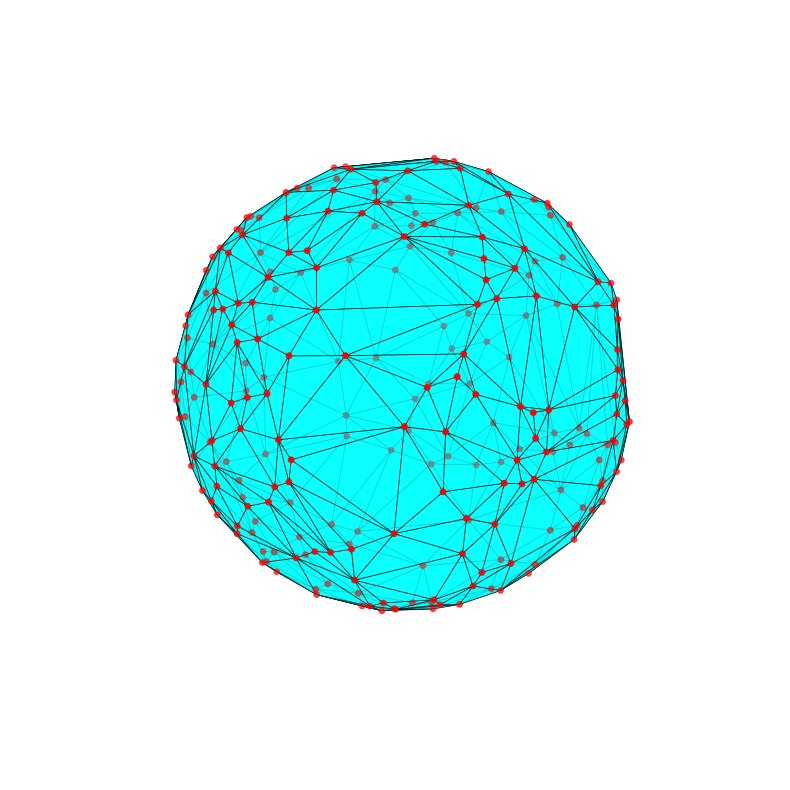

Sample 1: V=250, F=496 | Target: (0.985, 0.96) | Actual: (1.0000, 0.9913)


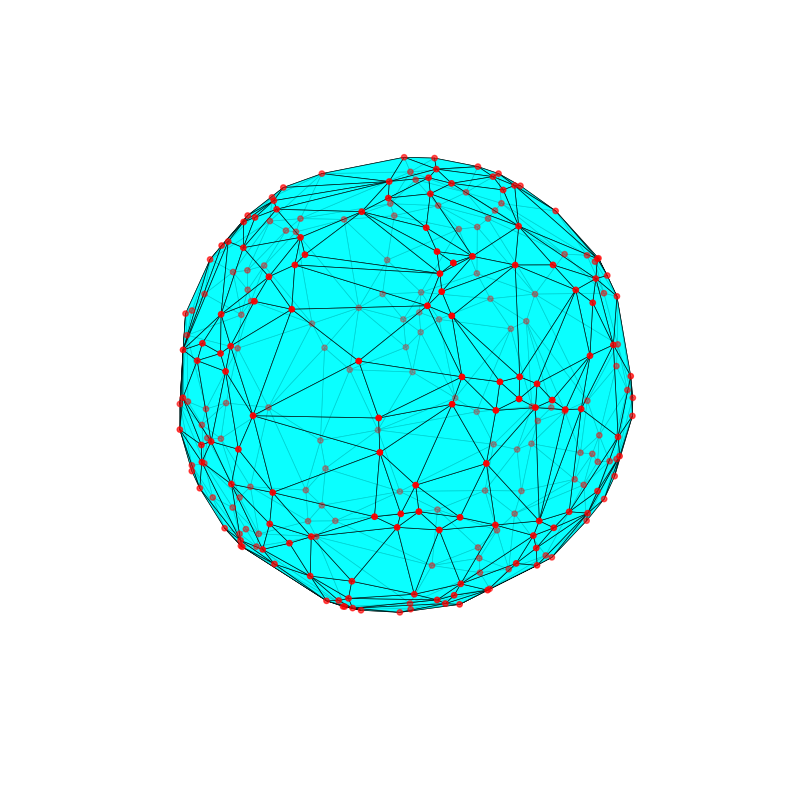

Sample 2: V=250, F=496 | Target: (0.985, 0.96) | Actual: (1.0000, 0.9910)


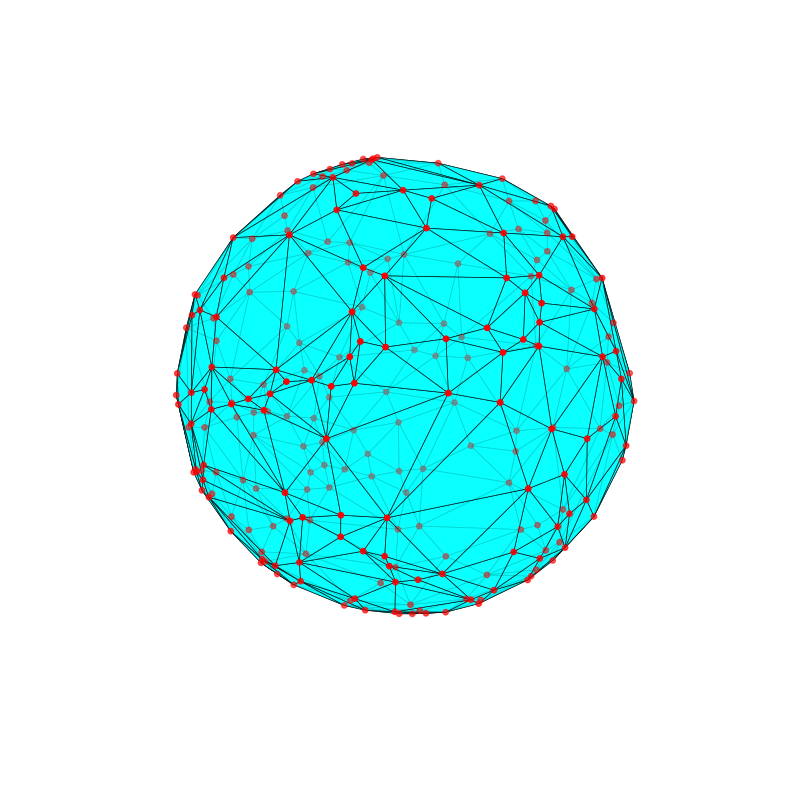

Sample 3: V=250, F=496 | Target: (0.985, 0.96) | Actual: (1.0000, 0.9915)


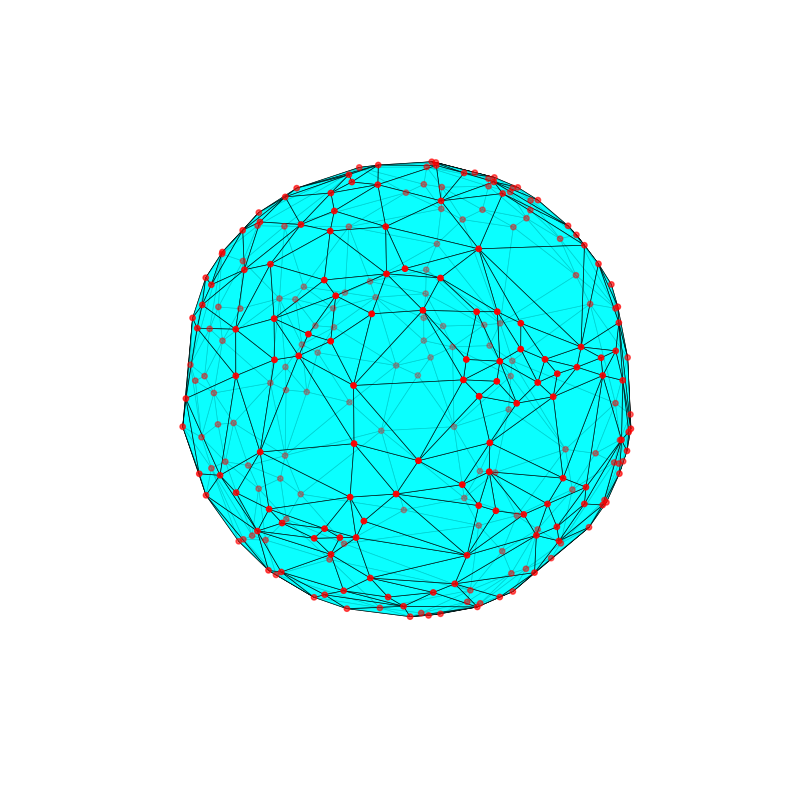

Sample 4: V=249, F=494 | Target: (0.985, 0.96) | Actual: (1.0000, 0.9904)


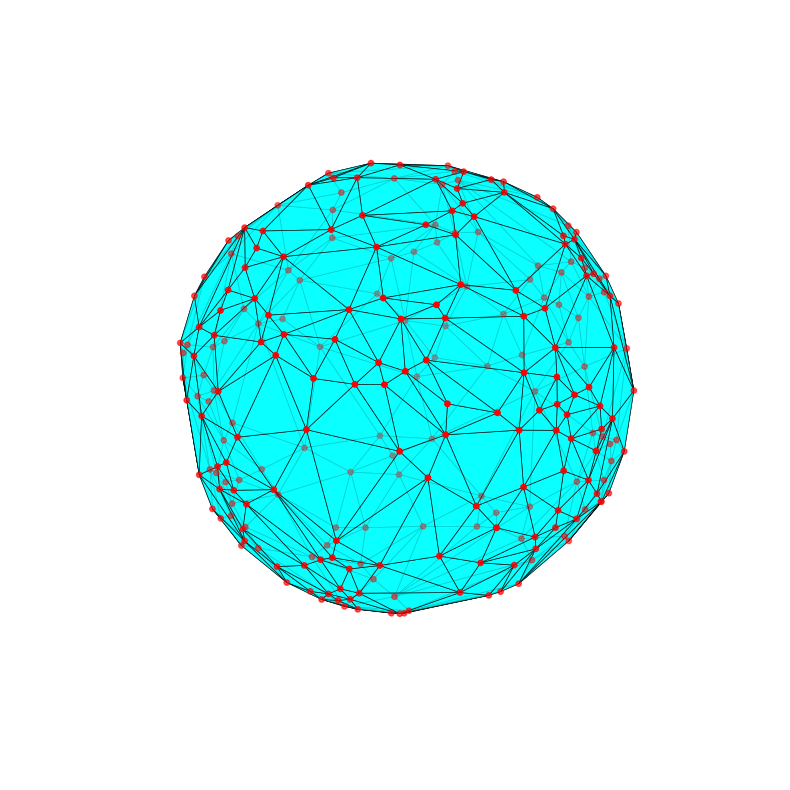

Sample 5: V=250, F=496 | Target: (0.985, 0.96) | Actual: (1.0000, 0.9915)

--- Final Evaluation ---
Validity Rate: 100.0%
Mean Error Mu: 0.0150
Mean Error Psi: 0.0311


In [39]:
if __name__ == "__main__":
  evaluate_generator(target_mu=0.985, target_psi=0.960, num_samples=5)